In [2]:
import shap 
import pandas as pd  
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from scipy.stats import spearmanr

C:\Users\agamv\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
df = pd.read_csv("TCGA_GBM_LGG_Mutations_all.csv")
df = df.drop(columns=['Project', 'Case_ID', 'Primary_Diagnosis'])
df = df[~df['Gender'].isin(['--', 'not reported'])]
df = df[~df['Age_at_diagnosis'].isin(['--', 'not reported'])]
df = df[~df['Race'].isin(['--', 'not reported'])]

In [11]:
def parse_age(age_str):
    parts = age_str.split()
    years = int(parts[0])
    days = int(parts[2]) if len(parts) >= 4 else 0
    return round(years + days / 365.25, 2)

In [12]:
df['Age_at_diagnosis'] = df['Age_at_diagnosis'].apply(parse_age)

mutation_cols = ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16',
                 'PIK3CA', 'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1',
                 'BCOR', 'CSMD3', 'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']
for col in mutation_cols:
    df[col] = df[col].map({'MUTATED': 1, 'NOT_MUTATED': 0})

df['Grade'] = df['Grade'].map({'LGG': 0, 'GBM': 1})

print(df.shape)
print(df['Grade'].value_counts())
print(df.dtypes)
print(df.isnull().sum())

(839, 24)
Grade
0    487
1    352
Name: count, dtype: int64
Grade                 int64
Gender               object
Age_at_diagnosis    float64
Race                 object
IDH1                  int64
TP53                  int64
ATRX                  int64
PTEN                  int64
EGFR                  int64
CIC                   int64
MUC16                 int64
PIK3CA                int64
NF1                   int64
PIK3R1                int64
FUBP1                 int64
RB1                   int64
NOTCH1                int64
BCOR                  int64
CSMD3                 int64
SMARCA4               int64
GRIN2A                int64
IDH2                  int64
FAT4                  int64
PDGFRA                int64
dtype: object
Grade               0
Gender              0
Age_at_diagnosis    0
Race                0
IDH1                0
TP53                0
ATRX                0
PTEN                0
EGFR                0
CIC                 0
MUC16               0
PIK3CA      

In [13]:
X = df.drop(columns=['Grade', 'Gender', 'Race'])
Y = df.Grade

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
background = shap.kmeans(X_train, 50)

clf = LogisticRegression(max_iter=10000, random_state=0)
clf.fit(X_train, y_train)
acc = accuracy_score(y_test, clf.predict(X_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")
explainer_lr = shap.KernelExplainer(clf.predict_proba, background)
shap_values_lr = explainer_lr.shap_values(X_test)

Logistic Regression model accuracy: 86.31%


100%|██████████| 168/168 [00:09<00:00, 17.22it/s]


In [14]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
y_pred_rf = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest accuracy: {accuracy * 100:.2f}%')
explainer_rf = shap.KernelExplainer(classifier.predict_proba, background)
shap_values_rf = explainer_rf.shap_values(X_test)


Random Forest accuracy: 80.95%


100%|██████████| 168/168 [01:46<00:00,  1.58it/s]


In [16]:
params = {
    'objective': 'binary:logistic',
    'max_depth': 4,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'alpha': 10
}
model = XGBClassifier(**params)
model.fit(X_train, y_train)
y_pred_xgb = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_xgb)
print("XGBoost accuracy:", accuracy)
print(classification_report(y_test, y_pred_xgb))
explainer_xgb = shap.KernelExplainer(lambda x: model.predict_proba(x), background)
shap_values_xgb = explainer_xgb.shap_values(X_test)

XGBoost accuracy: 0.8690476190476191
              precision    recall  f1-score   support

           0       0.92      0.82      0.87        89
           1       0.82      0.92      0.87        79

    accuracy                           0.87       168
   macro avg       0.87      0.87      0.87       168
weighted avg       0.88      0.87      0.87       168



100%|██████████| 168/168 [00:12<00:00, 13.08it/s]


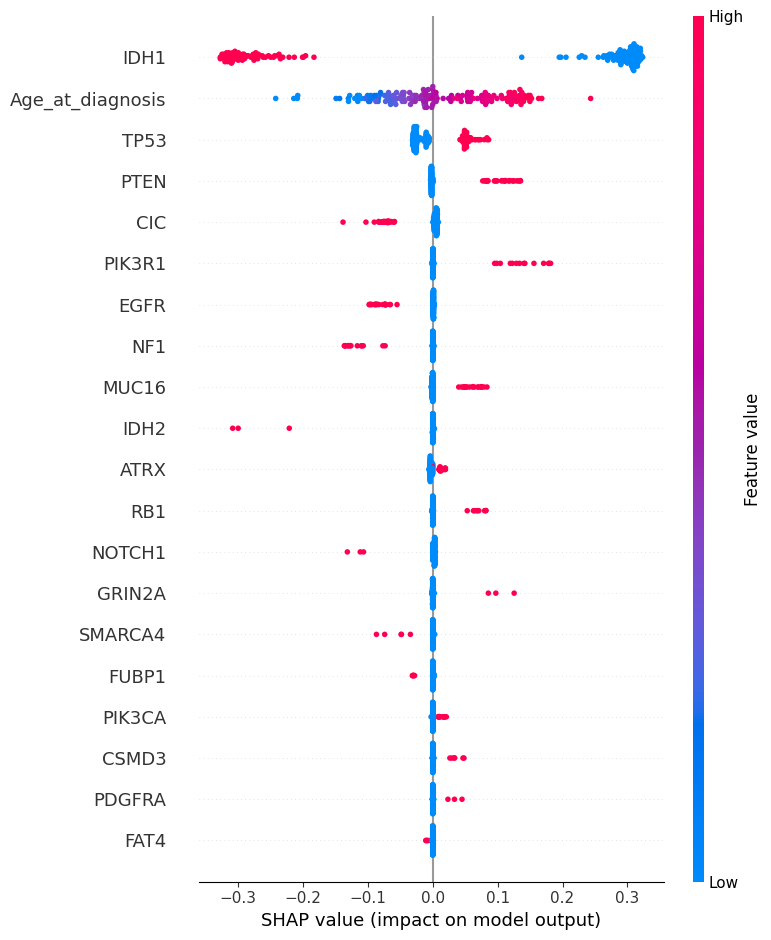

In [ ]:
shap.summary_plot(shap_values_lr[:, :, 1],  X_test, show=False)

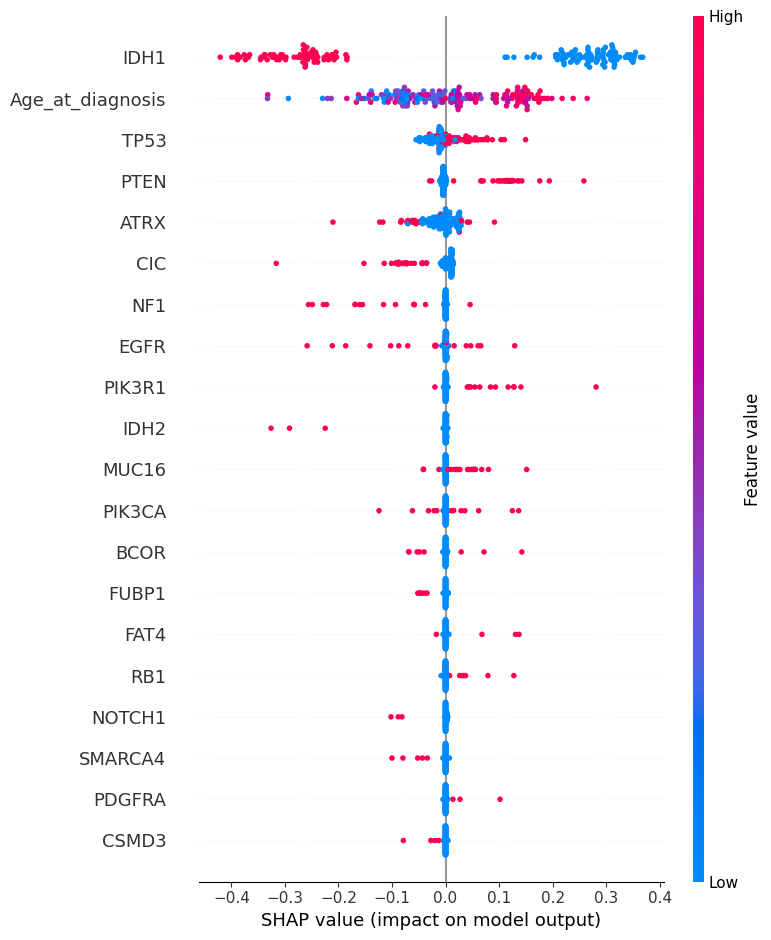

In [19]:
shap.summary_plot(shap_values_rf[:, :, 1],  X_test, show=False)


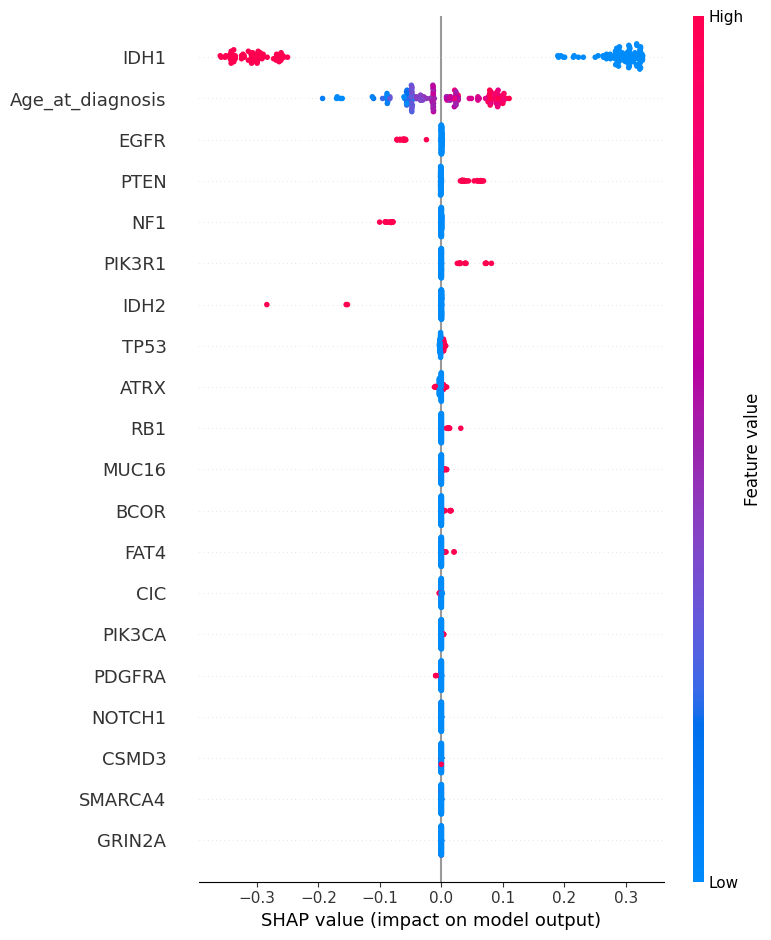

In [20]:
shap.summary_plot(shap_values_xgb[:, :, 1], X_test, show=False)

In [22]:
weight_vector = {
    "IDH1": 1.0, "IDH2": 1.0,
    "ATRX": 0.75, "TP53": 0.75,
    "EGFR": 0.5, "PTEN": 0.5, "NF1": 0.5,
    "CIC": 0.25, "MUC16": 0.25, "PIK3CA": 0.25, "PIK3R1": 0.25,
    "FUBP1": 0.25, "RB1": 0.25, "NOTCH1": 0.25, "BCOR": 0.25,
    "CSMD3": 0.25, "SMARCA4": 0.25, "GRIN2A": 0.25, "FAT4": 0.25,
    "PDGFRA": 0.25,
    "Age_at_diagnosis": 0.6,
}
assert set(X.columns) - set(weight_vector.keys()) == set()
weight_array = np.array([weight_vector[col] for col in X.columns])

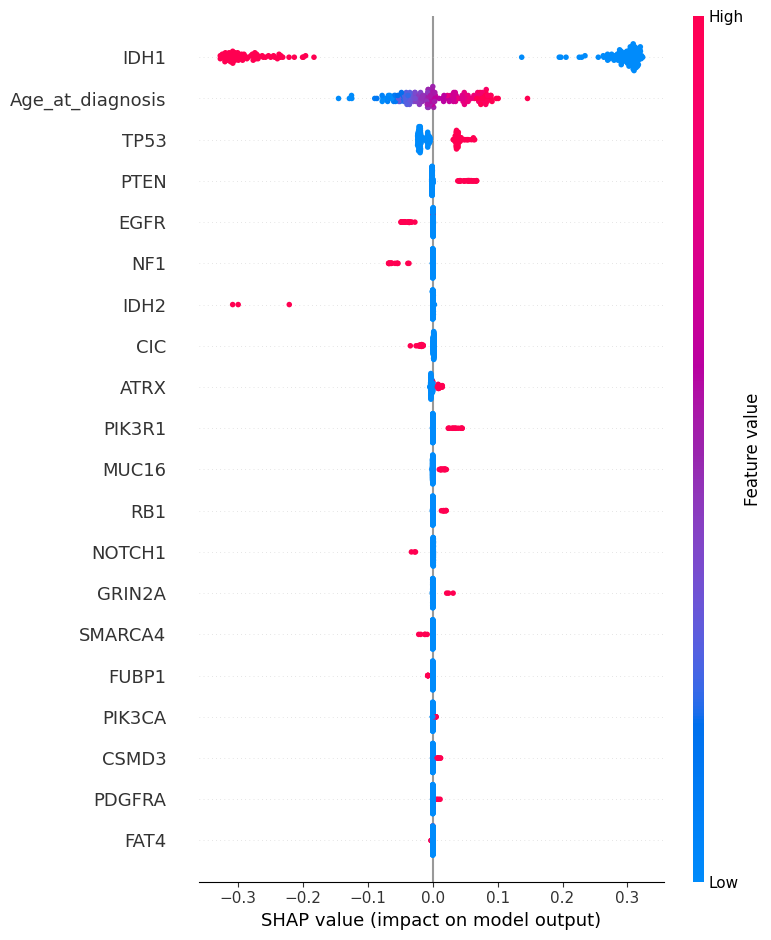

In [24]:
weighted_shap_lr  = shap_values_lr[:, :, 1]  * weight_array
weighted_shap_rf  = shap_values_rf[:, :, 1]  * weight_array
weighted_shap_xgb = shap_values_xgb[:, :, 1] * weight_array

shap.summary_plot(weighted_shap_lr,  X_test, show=False)


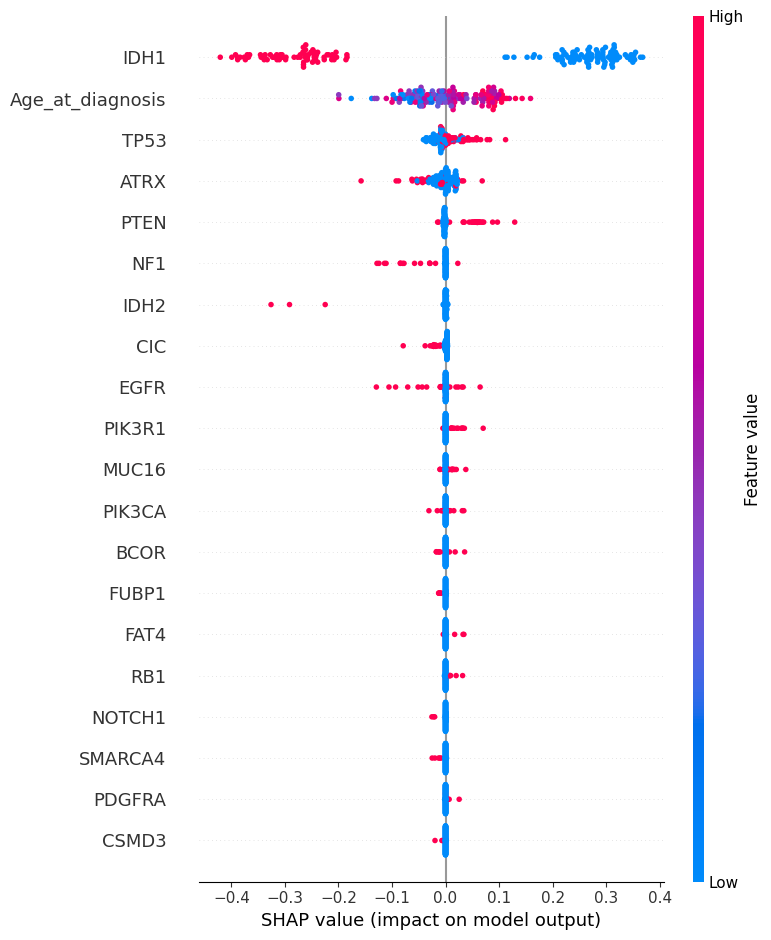

In [25]:
shap.summary_plot(weighted_shap_rf,  X_test, show=False)


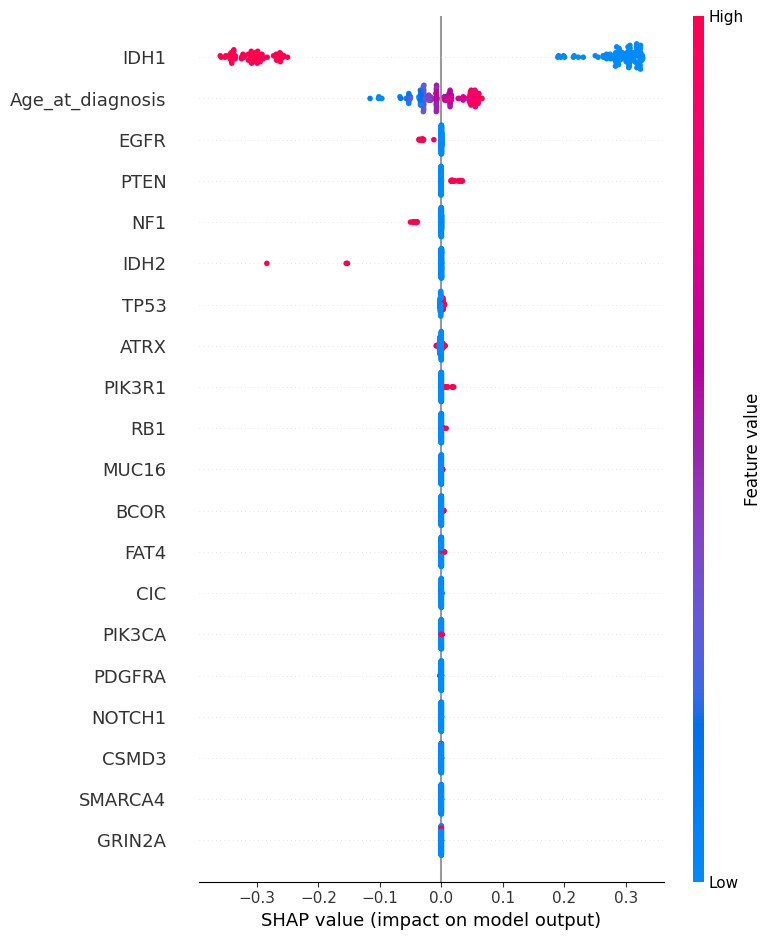

In [26]:
shap.summary_plot(weighted_shap_xgb, X_test, show=False)

In [27]:
raw_importance_lr  = np.abs(shap_values_lr[:, :, 1]).mean(axis=0)
raw_importance_rf  = np.abs(shap_values_rf[:, :, 1]).mean(axis=0)
raw_importance_xgb = np.abs(shap_values_xgb[:, :, 1]).mean(axis=0)

weighted_importance_lr  = np.abs(weighted_shap_lr).mean(axis=0)
weighted_importance_rf  = np.abs(weighted_shap_rf).mean(axis=0)
weighted_importance_xgb = np.abs(weighted_shap_xgb).mean(axis=0)

In [28]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight':  weight_array,
    'LR':      weighted_importance_lr,
    'RF':      weighted_importance_rf,
    'XGB':     weighted_importance_xgb
}).sort_values('LR', ascending=False)
print(importance_df)

             Feature  Weight        LR        RF       XGB
1               IDH1    1.00  0.288677  0.275833  0.299089
0   Age_at_diagnosis    0.60  0.045524  0.057137  0.034627
2               TP53    0.75  0.025270  0.018879  0.001694
4               PTEN    0.50  0.010118  0.011311  0.004355
5               EGFR    0.50  0.005606  0.004763  0.004437
9                NF1    0.50  0.005339  0.006289  0.003826
18              IDH2    1.00  0.005070  0.005354  0.003608
6                CIC    0.25  0.003966  0.004892  0.000059
3               ATRX    0.75  0.003427  0.016679  0.001513
10            PIK3R1    0.25  0.002917  0.001966  0.000997
7              MUC16    0.25  0.001947  0.001281  0.000147
12               RB1    0.25  0.000959  0.000600  0.000190
13            NOTCH1    0.25  0.000946  0.000596  0.000008
17            GRIN2A    0.25  0.000489  0.000254  0.000005
16           SMARCA4    0.25  0.000460  0.000535  0.000005
11             FUBP1    0.25  0.000384  0.000621  0.0000

In [29]:
print("\n=== Weighted SHAP Spearman (sanity check) ===")
corr_lr,  p_lr  = spearmanr(importance_df['Weight'], importance_df['LR'])
corr_rf,  p_rf  = spearmanr(importance_df['Weight'], importance_df['RF'])
corr_xgb, p_xgb = spearmanr(importance_df['Weight'], importance_df['XGB'])
print(f"LR  — ρ: {corr_lr:.4f},  p: {p_lr:.4f}")
print(f"RF  — ρ: {corr_rf:.4f},  p: {p_rf:.4f}")
print(f"XGB — ρ: {corr_xgb:.4f}, p: {p_xgb:.4f}")

print("\n=== Raw SHAP Spearman (primary validation) ===")
corr_raw_lr,  p_raw_lr  = spearmanr(weight_array, raw_importance_lr)
corr_raw_rf,  p_raw_rf  = spearmanr(weight_array, raw_importance_rf)
corr_raw_xgb, p_raw_xgb = spearmanr(weight_array, raw_importance_xgb)
print(f"LR  — ρ: {corr_raw_lr:.4f},  p: {p_raw_lr:.4f}")
print(f"RF  — ρ: {corr_raw_rf:.4f},  p: {p_raw_rf:.4f}")
print(f"XGB — ρ: {corr_raw_xgb:.4f}, p: {p_raw_xgb:.4f}")


=== Weighted SHAP Spearman (sanity check) ===
LR  — ρ: 0.8016,  p: 0.0000
RF  — ρ: 0.8277,  p: 0.0000
XGB — ρ: 0.8061, p: 0.0000

=== Raw SHAP Spearman (primary validation) ===
LR  — ρ: 0.6593,  p: 0.0011
RF  — ρ: 0.7621,  p: 0.0001
XGB — ρ: 0.7517, p: 0.0001


In [30]:
rank_df = pd.DataFrame({
    'Feature':      list(X.columns),
    'Weight':       weight_array,
    'Raw_Rank_LR':  pd.Series(raw_importance_lr).rank(ascending=False).astype(int).values,
    'Wtd_Rank_LR':  pd.Series(weighted_importance_lr).rank(ascending=False).astype(int).values,
    'Raw_Rank_RF':  pd.Series(raw_importance_rf).rank(ascending=False).astype(int).values,
    'Wtd_Rank_RF':  pd.Series(weighted_importance_rf).rank(ascending=False).astype(int).values,
    'Raw_Rank_XGB': pd.Series(raw_importance_xgb).rank(ascending=False).astype(int).values,
    'Wtd_Rank_XGB': pd.Series(weighted_importance_xgb).rank(ascending=False).astype(int).values,
})
rank_df['Shift_LR']  = rank_df['Raw_Rank_LR']  - rank_df['Wtd_Rank_LR']
rank_df['Shift_RF']  = rank_df['Raw_Rank_RF']  - rank_df['Wtd_Rank_RF']
rank_df['Shift_XGB'] = rank_df['Raw_Rank_XGB'] - rank_df['Wtd_Rank_XGB']

print("\n=== Rank Shift Analysis ===")
print(rank_df[['Feature', 'Weight',
               'Raw_Rank_LR', 'Wtd_Rank_LR', 'Shift_LR',
               'Raw_Rank_RF', 'Wtd_Rank_RF', 'Shift_RF',
               'Raw_Rank_XGB', 'Wtd_Rank_XGB', 'Shift_XGB']]
      .sort_values('Shift_LR', ascending=False)
      .to_string(index=False))


=== Rank Shift Analysis ===
         Feature  Weight  Raw_Rank_LR  Wtd_Rank_LR  Shift_LR  Raw_Rank_RF  Wtd_Rank_RF  Shift_RF  Raw_Rank_XGB  Wtd_Rank_XGB  Shift_XGB
            IDH2    1.00           10            7         3           10            7         3             7             6          1
            EGFR    0.50            7            5         2            8            9        -1             3             3          0
             NF1    0.50            8            6         2            7            6         1             5             5          0
            ATRX    0.75           11            9         2            5            4         1             9             8          1
Age_at_diagnosis    0.60            2            2         0            2            2         0             2             2          0
            PTEN    0.50            4            4         0            4            5        -1             4             4          0
            TP53   

In [31]:
y_pred_lr_arr = clf.predict(X_test)
misclassified_lr  = np.where(y_pred_lr_arr != y_test.values)[0]
misclassified_rf  = np.where(y_pred_rf      != y_test.values)[0]
misclassified_xgb = np.where(y_pred_xgb     != y_test.values)[0]

print(f"LR misclassified:  {len(misclassified_lr)}")
print(f"RF misclassified:  {len(misclassified_rf)}")
print(f"XGB misclassified: {len(misclassified_xgb)}")

feature_names = list(X.columns)

def get_top_features(shap_row, feature_names, n=3):
    abs_vals = np.abs(shap_row)
    top_idx = np.argsort(abs_vals)[::-1][:n]
    return [(feature_names[i], round(shap_row[i], 4)) for i in top_idx]

def misclassification_report(model_name, misclassified_idx,
                              raw_shap, weighted_shap,
                              y_test_local, y_pred_local,
                              feature_names, weight_vector):
    records = []
    for i in misclassified_idx:
        true_label = 'GBM' if y_test_local.values[i] == 1 else 'LGG'
        pred_label = 'GBM' if y_pred_local[i] == 1 else 'LGG'
        raw_top    = get_top_features(raw_shap[i], feature_names)
        wtd_top    = get_top_features(weighted_shap[i], feature_names)
        raw_score  = np.mean([weight_vector[f] for f, _ in raw_top])
        wtd_score  = np.mean([weight_vector[f] for f, _ in wtd_top])
        records.append({
            'Model': model_name, 'Sample': i,
            'True': true_label, 'Predicted': pred_label,
            'Raw_Top3': ', '.join([f for f, _ in raw_top]),
            'Wtd_Top3': ', '.join([f for f, _ in wtd_top]),
            'Raw_ClinScore': round(raw_score, 3),
            'Wtd_ClinScore': round(wtd_score, 3),
            'Improvement': round(wtd_score - raw_score, 3)
        })
    return pd.DataFrame(records)

LR misclassified:  23
RF misclassified:  32
XGB misclassified: 22


In [32]:
df_lr  = misclassification_report('LR',  misclassified_lr,
    shap_values_lr[:, :, 1],  weighted_shap_lr,
    y_test, y_pred_lr_arr, feature_names, weight_vector)

df_rf  = misclassification_report('RF',  misclassified_rf,
    shap_values_rf[:, :, 1],  weighted_shap_rf,
    y_test, y_pred_rf, feature_names, weight_vector)

df_xgb = misclassification_report('XGB', misclassified_xgb,
    shap_values_xgb[:, :, 1], weighted_shap_xgb,
    y_test, y_pred_xgb, feature_names, weight_vector)

all_cases = pd.concat([df_lr, df_rf, df_xgb], ignore_index=True)
print(all_cases.to_string(index=False))
print(f"\nCases improved: {(all_cases['Improvement'] > 0).sum()} / {len(all_cases)}")
print(f"Mean raw clinical score:      {all_cases['Raw_ClinScore'].mean():.3f}")
print(f"Mean weighted clinical score: {all_cases['Wtd_ClinScore'].mean():.3f}")
print(f"Mean improvement overall:     {all_cases['Improvement'].mean():.3f}")
improved = all_cases[all_cases['Improvement'] > 0]
print(f"\nAmong improved cases only:")
print(f"Mean improvement: {improved['Improvement'].mean():.3f}")
print(f"Max improvement:  {improved['Improvement'].max():.3f}")

Model  Sample True Predicted                       Raw_Top3                       Wtd_Top3  Raw_ClinScore  Wtd_ClinScore  Improvement
   LR       2  LGG       GBM    IDH1, Age_at_diagnosis, NF1    IDH1, Age_at_diagnosis, NF1          0.700          0.700        0.000
   LR       4  GBM       LGG   IDH1, Age_at_diagnosis, TP53   IDH1, Age_at_diagnosis, TP53          0.783          0.783        0.000
   LR       6  LGG       GBM   IDH1, PTEN, Age_at_diagnosis   IDH1, PTEN, Age_at_diagnosis          0.700          0.700        0.000
   LR      13  LGG       GBM   IDH1, Age_at_diagnosis, PTEN   IDH1, Age_at_diagnosis, PTEN          0.700          0.700        0.000
   LR      30  LGG       GBM   IDH1, Age_at_diagnosis, TP53   IDH1, Age_at_diagnosis, TP53          0.783          0.783        0.000
   LR      43  LGG       GBM   IDH1, Age_at_diagnosis, TP53   IDH1, Age_at_diagnosis, TP53          0.783          0.783        0.000
   LR      45  LGG       GBM   IDH1, Age_at_diagnosis, EGFR   

In [33]:
# ── Sensitivity Analysis ──────────────────────────────────────────────────────

# Test A — Perturb each tier weight by +/- 0.1
schemes = {
    'Original':  {'IDH1':1.0,'IDH2':1.0,'ATRX':0.75,'TP53':0.75,'EGFR':0.5,'PTEN':0.5,'NF1':0.5,'Age_at_diagnosis':0.6,'CIC':0.25,'MUC16':0.25,'PIK3CA':0.25,'PIK3R1':0.25,'FUBP1':0.25,'RB1':0.25,'NOTCH1':0.25,'BCOR':0.25,'CSMD3':0.25,'SMARCA4':0.25,'GRIN2A':0.25,'FAT4':0.25,'PDGFRA':0.25},
    'Plus_0.1':  {'IDH1':1.0,'IDH2':1.0,'ATRX':0.85,'TP53':0.85,'EGFR':0.6,'PTEN':0.6,'NF1':0.6,'Age_at_diagnosis':0.7,'CIC':0.35,'MUC16':0.35,'PIK3CA':0.35,'PIK3R1':0.35,'FUBP1':0.35,'RB1':0.35,'NOTCH1':0.35,'BCOR':0.35,'CSMD3':0.35,'SMARCA4':0.35,'GRIN2A':0.35,'FAT4':0.35,'PDGFRA':0.35},
    'Minus_0.1': {'IDH1':1.0,'IDH2':1.0,'ATRX':0.65,'TP53':0.65,'EGFR':0.4,'PTEN':0.4,'NF1':0.4,'Age_at_diagnosis':0.5,'CIC':0.15,'MUC16':0.15,'PIK3CA':0.15,'PIK3R1':0.15,'FUBP1':0.15,'RB1':0.15,'NOTCH1':0.15,'BCOR':0.15,'CSMD3':0.15,'SMARCA4':0.15,'GRIN2A':0.15,'FAT4':0.15,'PDGFRA':0.15},
    'Scheme_B':  {'IDH1':1.0,'IDH2':1.0,'ATRX':0.7,'TP53':0.7,'EGFR':0.4,'PTEN':0.4,'NF1':0.4,'Age_at_diagnosis':0.6,'CIC':0.1,'MUC16':0.1,'PIK3CA':0.1,'PIK3R1':0.1,'FUBP1':0.1,'RB1':0.1,'NOTCH1':0.1,'BCOR':0.1,'CSMD3':0.1,'SMARCA4':0.1,'GRIN2A':0.1,'FAT4':0.1,'PDGFRA':0.1},
    'Scheme_C':  {'IDH1':1.0,'IDH2':1.0,'ATRX':0.5,'TP53':0.5,'EGFR':0.25,'PTEN':0.25,'NF1':0.25,'Age_at_diagnosis':0.6,'CIC':0.1,'MUC16':0.1,'PIK3CA':0.1,'PIK3R1':0.1,'FUBP1':0.1,'RB1':0.1,'NOTCH1':0.1,'BCOR':0.1,'CSMD3':0.1,'SMARCA4':0.1,'GRIN2A':0.1,'FAT4':0.1,'PDGFRA':0.1},
}

print("=== Sensitivity Analysis — Spearman rho under alternative weight schemes ===")
print(f"{'Scheme':<12} {'LR_raw':>8} {'RF_raw':>8} {'XGB_raw':>8} {'LR_wtd':>8} {'RF_wtd':>8} {'XGB_wtd':>8}")

for name, wv in schemes.items():
    wa = np.array([wv[col] for col in X.columns])
    
    # Raw Spearman (against this scheme's weights)
    rho_lr_raw,  _ = spearmanr(wa, raw_importance_lr)
    rho_rf_raw,  _ = spearmanr(wa, raw_importance_rf)
    rho_xgb_raw, _ = spearmanr(wa, raw_importance_xgb)
    
    # Weighted importance under this scheme
    w_lr  = np.abs(shap_values_lr[:, :, 1]  * wa).mean(axis=0)
    w_rf  = np.abs(shap_values_rf[:, :, 1]  * wa).mean(axis=0)
    w_xgb = np.abs(shap_values_xgb[:, :, 1] * wa).mean(axis=0)
    
    rho_lr_wtd,  _ = spearmanr(wa, w_lr)
    rho_rf_wtd,  _ = spearmanr(wa, w_rf)
    rho_xgb_wtd, _ = spearmanr(wa, w_xgb)
    
    print(f"{name:<12} {rho_lr_raw:>8.4f} {rho_rf_raw:>8.4f} {rho_xgb_raw:>8.4f} {rho_lr_wtd:>8.4f} {rho_rf_wtd:>8.4f} {rho_xgb_wtd:>8.4f}")

# Check rank shift stability under alternative schemes
print("\n=== Rank shift stability — do IDH2, ATRX get promoted and CIC, PIK3R1 get demoted? ===")
for name, wv in schemes.items():
    wa = np.array([wv[col] for col in X.columns])
    w_lr  = np.abs(shap_values_lr[:, :, 1]  * wa).mean(axis=0)
    
    raw_ranks = pd.Series(raw_importance_lr).rank(ascending=False).astype(int).values
    wtd_ranks = pd.Series(w_lr).rank(ascending=False).astype(int).values
    
    features = list(X.columns)
    shifts = {features[i]: int(raw_ranks[i]) - int(wtd_ranks[i]) for i in range(len(features))}
    
    print(f"\n{name}: IDH2={shifts['IDH2']:+d}  ATRX={shifts['ATRX']:+d}  CIC={shifts['CIC']:+d}  PIK3R1={shifts['PIK3R1']:+d}")

=== Sensitivity Analysis — Spearman rho under alternative weight schemes ===
Scheme         LR_raw   RF_raw  XGB_raw   LR_wtd   RF_wtd  XGB_wtd
Original       0.6593   0.7621   0.7517   0.8016   0.8277   0.8061
Plus_0.1       0.6593   0.7621   0.7517   0.7644   0.7994   0.8061
Minus_0.1      0.6593   0.7621   0.7517   0.8351   0.8478   0.8307
Scheme_B       0.6593   0.7621   0.7517   0.8351   0.8478   0.8307
Scheme_C       0.6742   0.7681   0.7711   0.8538   0.8523   0.8470

=== Rank shift stability — do IDH2, ATRX get promoted and CIC, PIK3R1 get demoted? ===

Original: IDH2=+3  ATRX=+2  CIC=-3  PIK3R1=-4

Plus_0.1: IDH2=+2  ATRX=+1  CIC=-2  PIK3R1=-3

Minus_0.1: IDH2=+5  ATRX=+3  CIC=-4  PIK3R1=-4

Scheme_B: IDH2=+5  ATRX=+3  CIC=-4  PIK3R1=-4

Scheme_C: IDH2=+6  ATRX=+3  CIC=-4  PIK3R1=-4


In [34]:
# ── Demographic Stress Test ───────────────────────────────────────────────────
# Re-include Gender and Race in the feature matrix with clinical weight = 0.0

df_demo = df.copy()

# Encode Gender and Race numerically
df_demo['Gender'] = df_demo['Gender'].map({'Male': 1, 'Female': 0})
df_demo['Race']   = pd.Categorical(df_demo['Race']).codes

# Build new feature matrix including Gender and Race
X_demo = df_demo.drop(columns=['Grade'])
Y_demo = df_demo['Grade']

# Same split seed
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_demo, Y_demo, test_size=0.2, random_state=42)
background_d = shap.kmeans(X_train_d, 50)

# Weight vector — Gender and Race assigned 0.0
weight_vector_demo = {**weight_vector, 'Gender': 0.0, 'Race': 0.0}
assert set(X_demo.columns) - set(weight_vector_demo.keys()) == set()
weight_array_demo = np.array([weight_vector_demo[col] for col in X_demo.columns])

# Train and explain — LR only for efficiency (pattern will generalise)
clf_demo = LogisticRegression(max_iter=10000, random_state=0)
clf_demo.fit(X_train_d, y_train_d)
print(f"LR accuracy (with demographics): {accuracy_score(y_test_d, clf_demo.predict(X_test_d))*100:.2f}%")

explainer_demo = shap.KernelExplainer(clf_demo.predict_proba, background_d)
shap_values_demo = explainer_demo.shap_values(X_test_d)

# Raw importance rankings
raw_imp_demo = np.abs(shap_values_demo[:, :, 1]).mean(axis=0)
feature_names_demo = list(X_demo.columns)

raw_rank_demo = pd.DataFrame({
    'Feature': feature_names_demo,
    'Weight':  weight_array_demo,
    'Raw_Importance': raw_imp_demo
}).sort_values('Raw_Importance', ascending=False)

print("\n=== Raw SHAP rankings with Gender and Race included ===")
print(raw_rank_demo[['Feature', 'Weight', 'Raw_Importance']].to_string(index=False))

# Weighted importance rankings
wtd_shap_demo = shap_values_demo[:, :, 1] * weight_array_demo
wtd_imp_demo  = np.abs(wtd_shap_demo).mean(axis=0)

wtd_rank_demo = pd.DataFrame({
    'Feature': feature_names_demo,
    'Weight':  weight_array_demo,
    'Wtd_Importance': wtd_imp_demo
}).sort_values('Wtd_Importance', ascending=False)

print("\n=== Weighted SHAP rankings (Gender and Race should move to bottom) ===")
print(wtd_rank_demo[['Feature', 'Weight', 'Wtd_Importance']].to_string(index=False))

# Spearman
rho_demo_raw, p_demo_raw = spearmanr(weight_array_demo, raw_imp_demo)
rho_demo_wtd, p_demo_wtd = spearmanr(weight_array_demo, wtd_imp_demo)
print(f"\nRaw Spearman (with demographics): ρ = {rho_demo_raw:.4f}, p = {p_demo_raw:.4f}")
print(f"Wtd Spearman (with demographics): ρ = {rho_demo_wtd:.4f}, p = {p_demo_wtd:.4f}")

# Where do Gender and Race appear in raw vs weighted rankings?
gender_raw_rank = raw_rank_demo['Feature'].tolist().index('Gender') + 1
race_raw_rank   = raw_rank_demo['Feature'].tolist().index('Race') + 1
gender_wtd_rank = wtd_rank_demo['Feature'].tolist().index('Gender') + 1
race_wtd_rank   = wtd_rank_demo['Feature'].tolist().index('Race') + 1

print(f"\nGender — raw rank: {gender_raw_rank}, weighted rank: {gender_wtd_rank}")
print(f"Race   — raw rank: {race_raw_rank}, weighted rank: {race_wtd_rank}")

LR accuracy (with demographics): 86.90%


100%|██████████| 168/168 [00:09<00:00, 16.87it/s]


=== Raw SHAP rankings with Gender and Race included ===
         Feature  Weight  Raw_Importance
            IDH1    1.00        0.286182
Age_at_diagnosis    0.60        0.077141
            TP53    0.75        0.035907
            PTEN    0.50        0.018957
             CIC    0.25        0.014533
            EGFR    0.50        0.012185
          PIK3R1    0.25        0.011040
             NF1    0.50        0.010057
           MUC16    0.25        0.007344
            Race    0.00        0.006411
            ATRX    0.75        0.005096
            IDH2    1.00        0.004871
          NOTCH1    0.25        0.004584
             RB1    0.25        0.003854
          GRIN2A    0.25        0.001917
           FUBP1    0.25        0.001890
         SMARCA4    0.25        0.001816
           CSMD3    0.25        0.001468
          Gender    0.00        0.001414
          PIK3CA    0.25        0.001133
          PDGFRA    0.25        0.000819
            FAT4    0.25        0.000196
